## Import Files And Loading The Data

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
insurence_data = pd.read_csv("insurance.csv")
insurence_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Check The Data Information

In [3]:
insurence_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurence_data.dtypes
insurence_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("✅ Null Values")
insurence_data.isnull().sum()

✅ Null Values


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Check The Duplicates Values In The Data

In [6]:
insurence_data[insurence_data.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## Drop The Duplicated Values ⌫

In [7]:
insurence_data = insurence_data.drop_duplicates()

In [8]:
insurence_data.duplicated().sum()

np.int64(0)

## Drop the un-usefull column

In [9]:
print("✅ Remove The Region Column In The Data Set ")
insurence_data.drop("region", axis=1)

✅ Remove The Region Column In The Data Set 


,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


## Visulaization the data

<Axes: xlabel='bmi', ylabel='charges'>

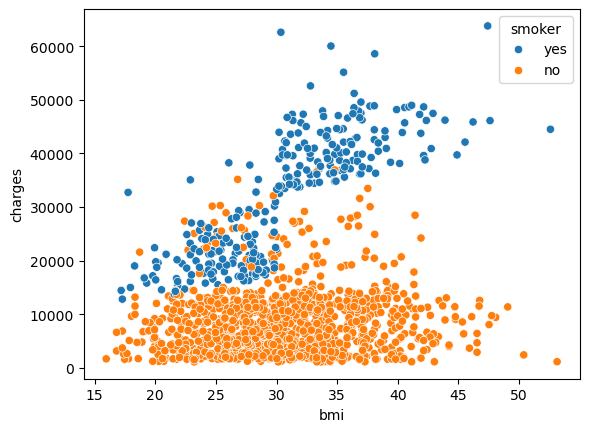

In [10]:
sns.scatterplot(x = insurence_data["bmi"], y = insurence_data["charges"], hue = insurence_data["smoker"])

In [11]:
X = insurence_data.drop(columns = ["charges"])
y = insurence_data["charges"]

X = pd.get_dummies(X, columns =["region"],drop_first = True, dtype = int)

In [12]:
print(X.head())

   age     sex     bmi  children smoker  region_northwest  region_southeast  \
0   19  female  27.900         0    yes                 0                 0   
1   18    male  33.770         1     no                 0                 1   
2   28    male  33.000         3     no                 0                 1   
3   33    male  22.705         0     no                 1                 0   
4   32    male  28.880         0     no                 1                 0   

   region_southwest  
0                 1  
1                 0  
2                 0  
3                 0  
4                 0  


## Encoding

In [13]:
X["sex"] = X["sex"].map({"female": 1, "male":0})
X["smoker"] = X["smoker"].map({"yes": 1, "no":0})

In [14]:
# interaction feature
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [15]:
X.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.9
1,18,0,33.770,1,0,0,1,0,0,0.0
2,28,0,33.000,3,0,0,1,0,0,0.0
3,33,0,22.705,0,0,1,0,0,0,0.0
4,32,0,28.880,0,0,1,0,0,0,0.0


## Train Test Split 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [17]:
X_train.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
1114,23,0,24.510,0,0,0,0,0,0,0.0
968,21,0,25.745,2,0,0,0,0,0,0.0
599,52,1,37.525,2,0,1,0,0,0,0.0
170,63,0,41.470,0,0,0,1,0,0,0.0
275,47,1,26.600,2,0,0,0,0,0,0.0


### LinearRegression Model 

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
y_pred

array([10523.6079388 ,  7367.8735991 , 13135.84644874, 36433.26400683,
        6250.15834871, 10954.15851975, 38351.1591297 ,  3225.35741753,
        9431.66106739, 11880.60753698, 13859.60869653, 29445.0135583 ,
       34835.87469572, 13663.57100719,  8825.68587473,  9802.43969134,
        2730.56083133, 37279.07130987,  4769.54504731,  5696.25363616,
        2804.48010755, 27476.89966146, 11656.84355548, 27739.04686065,
       37550.45926018,  4674.12193067, 47686.53754026, 39076.08770434,
       11835.17856697, 12705.57839241,  6550.78091122, 10637.41774133,
        2100.23895332, 12881.61429509, 60002.9278224 , 11506.61050387,
        5356.77220735,  7448.86631273, 19615.11556269, 10130.84250315,
        4293.36134335, 18540.65914903, 41308.92937108, 11732.50859474,
       11065.49609541,  4813.79294382,  3251.21230939,  9362.48740971,
        5846.05132527,  8276.34067688,  6046.83828656,  8134.20369857,
       25751.54712965,  2164.46890882,  9097.67458646,  9566.99074382,
      

In [22]:
y_test

900      8688.85885
1064     5708.86700
1256    11436.73815
298     38746.35510
237      4463.20510
           ...     
534     13831.11520
542     13887.20400
760      3925.75820
1284    47403.88000
1285     8534.67180
Name: charges, Length: 268, dtype: float64

## Import the Mean R Square and find values 

In [27]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r^Square",r2)
print("MAE",mae)

r^Square 0.8859571479859212
MAE 2831.6469777371826


In [ ]:
X_test.shape

In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n-1) / (n-p-1))
print("adjusted_rSquare",adjusted_r2)

In [ ]:
# Check underfitting and Overfitting 

In [ ]:
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

print("trainig data r2 : ", r2_train)
print("test data r2 : ",r2)